# DAMICORE: categorias de abuso

## Proposta de pesquisa

**Pergunta:** as categorias da fonte relacionadas à violência contra mulheres apresentam perfis contextuais recorrentes?

**Unidade de análise:** uma categoria da fonte, não uma pessoa ou uma denúncia. Todas as denúncias com vítima feminina entre janeiro e junho de 2026 contribuem para o perfil agregado de cada categoria elegível em que aparecem.

**Escopo operacional:** categorias sob `INTEGRIDADE`, `VIDA` ou `VIOLÊNCIA INSTITUCIONAL`, além de `LIBERDADE > SEXUAL` e da categoria da fonte sobre violência política de gênero. Essa regra da taxonomia da fonte é exploratória, não uma definição jurídica de violência contra a mulher.

**Representação:** todas as categorias recebem o mesmo vocabulário ordenado de contextos: idade, relação, ambiente, mês, canal de atendimento, tipo de denunciante, frequência, situação de emergência, grupo vulnerável, deficiência da vítima, gênero do suspeito e natureza jurídica do suspeito. Cada valor é serializado como prevalência de largura fixa por 10 mil denúncias, incluindo os valores zero. O suporte total da categoria fica fora do documento comprimido.

**Hipótese exploratória:** categorias com perfis normalizados semelhantes de idade, relação, ambiente, processo de registro e mês terão menores distâncias NCD, aparecerão próximas na árvore DAMICORE e tenderão a compartilhar um cluster.

A cadeia do experimento é: `prevalência contextual normalizada → matriz de distâncias NCD → diagnóstico de viés → árvore → clusters DAMICORE → grafos NetworkX`. A proposta é uma comparação exploratória de perfis contextuais; ela não confirma tipologias jurídicas.


In [1]:
from datetime import datetime
from pathlib import Path
from io import StringIO
from itertools import combinations
from math import log10
import os

import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
from matplotlib.patches import Patch
import networkx as nx
import pandas as pd
import psycopg
from Bio import Phylo
from damicore import estimate, run
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Execute este notebook a partir da raiz do repositório ou do diretório notebooks.")

DATABASE_URL = os.getenv("DISQUE100_DATABASE_URL", "postgresql:///disque100")
START_DATE = "2026-01-01"
END_DATE = "2026-07-01"
VICTIM_GENDER = "FEMININO"
MIN_REPORT_COUNT = 50
BIAS_WARNING_THRESHOLD = 0.70

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "damicore_abuse_categories_2026_h1"
WORK_DIR = ARTIFACT_DIR / "work"
CORPUS_DIR = WORK_DIR / "normalized-corpus"
RESULTS_DIR = ARTIFACT_DIR / "results"
CORPUS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


/Users/erickpatrickbarcelos/codes/research/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cobertura, escopo e contextos agregados

`source_hash` é usado somente dentro do PostgreSQL para contar denúncias distintas. O notebook recebe totais de cobertura e contagens agregadas, nunca denúncias individuais. Valores ausentes de idade, relação, ambiente e das novas dimensões recebem `DESCONHECIDO` para que toda denúncia permaneça representada.


In [2]:
category_sql = '''
nullif(concat_ws(' > ',
    nullif(trim(split_part(violation, '>', 1)), ''),
    nullif(trim(split_part(violation, '>', 2)), '')
), '')
'''

coverage_query = f'''
WITH reports AS (
    SELECT source_hash,
           bool_or(violation IS NOT NULL) AS has_violation,
           bool_or(({category_sql}) IS NOT NULL) AS has_category
    FROM public.disque100_reports
    WHERE registered_at >= %s AND registered_at < %s
      AND victim_gender = %s
    GROUP BY source_hash
)
SELECT count(*) AS female_reports,
       count(*) FILTER (WHERE has_category) AS reports_with_category,
       count(*) FILTER (WHERE NOT has_violation) AS reports_without_violation
FROM reports
'''

context_query = f'''
WITH report_values AS (
    SELECT DISTINCT
        source_hash,
        {category_sql} AS category,
        coalesce(victim_age_group, 'DESCONHECIDO') AS age_group,
        coalesce(victim_suspect_relationship, 'DESCONHECIDO') AS relationship,
        coalesce(violation_setting, 'DESCONHECIDO') AS setting,
        to_char(date_trunc('month', registered_at), 'YYYY-MM') AS month,
        coalesce(service_channel, 'DESCONHECIDO') AS service_channel,
        coalesce(reporter_type, 'DESCONHECIDO') AS reporter_type,
        coalesce(frequency, 'DESCONHECIDO') AS frequency,
        coalesce(emergency_status, 'DESCONHECIDO') AS emergency_status,
        coalesce(vulnerable_group, 'DESCONHECIDO') AS vulnerable_group,
        coalesce(victim_disability, 'DESCONHECIDO') AS victim_disability,
        coalesce(suspect_gender, 'DESCONHECIDO') AS suspect_gender,
        coalesce(suspect_legal_nature, 'DESCONHECIDO') AS suspect_legal_nature
    FROM public.disque100_reports
    WHERE registered_at >= %s AND registered_at < %s
      AND victim_gender = %s
), contexts AS (
    SELECT category, source_hash, 'denuncia'::text AS dimension, 'TODAS'::text AS value
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'faixa_etaria', age_group
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'relacao_vitima_suspeito', relationship
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'ambiente', setting
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'mes', month
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'canal_atendimento', service_channel
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'tipo_denunciante', reporter_type
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'frequencia', frequency
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'situacao_emergencia', emergency_status
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'grupo_vulneravel', vulnerable_group
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'deficiencia_vitima', victim_disability
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'genero_suspeito', suspect_gender
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'natureza_juridica_suspeito', suspect_legal_nature
    FROM report_values WHERE category IS NOT NULL
)
SELECT category, dimension, value, count(DISTINCT source_hash) AS report_count
FROM contexts
GROUP BY category, dimension, value
ORDER BY category, dimension, value
'''

parameters = (START_DATE, END_DATE, VICTIM_GENDER)
with psycopg.connect(DATABASE_URL) as connection:
    with connection.cursor() as cursor:
        cursor.execute(coverage_query, parameters)
        coverage = pd.DataFrame(cursor.fetchall(), columns=[column.name for column in cursor.description])
        cursor.execute(context_query, parameters)
        context_counts = pd.DataFrame(cursor.fetchall(), columns=[column.name for column in cursor.description])

display(coverage.rename(columns={
    "female_reports": "Denúncias com vítima feminina",
    "reports_with_category": "Denúncias com categoria",
    "reports_without_violation": "Denúncias sem violação",
}))
category_support = (
    context_counts.loc[context_counts["dimension"] == "denuncia", ["category", "report_count"]]
    .rename(columns={"report_count": "category_report_count"})
    .sort_values("category")
)

scope_mask = (
    category_support["category"].str.startswith(("INTEGRIDADE", "VIDA", "VIOLÊNCIA INSTITUCIONAL"))
    | category_support["category"].eq("LIBERDADE > SEXUAL")
    | category_support["category"].str.contains(
        "VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES", regex=False
    )
)
category_support["status"] = "incluída"
category_support.loc[~scope_mask, "status"] = "fora do escopo operacional"
category_support.loc[
    scope_mask & (category_support["category_report_count"] < MIN_REPORT_COUNT), "status"
] = "abaixo do suporte mínimo"

included_support = category_support.loc[category_support["status"] == "incluída"].copy()
excluded_categories = category_support.loc[category_support["status"] != "incluída"].copy()
included_categories = included_support["category"].tolist()

print(f"Categorias da fonte: {len(category_support)}")
print(f"Categorias incluídas no DAMICORE: {len(included_support)}")
print(f"Suporte mínimo: {MIN_REPORT_COUNT} denúncias distintas")
display(included_support)
display(excluded_categories)


,Denúncias com vítima feminina,Denúncias com categoria,Denúncias sem violação
0,189909,189909,0


Categorias da fonte: 48
Categorias incluídas no DAMICORE: 14
Suporte mínimo: 50 denúncias distintas


,category,category_report_count,status
827,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,56,incluída
3261,INTEGRIDADE > FÍSICA,154097,incluída
3443,INTEGRIDADE > NEGLIGÊNCIA,153638,incluída
3622,INTEGRIDADE > PATRIMONIAL,24187,incluída
3801,INTEGRIDADE > PSÍQUICA,160144,incluída
4526,LIBERDADE > SEXUAL,17293,incluída
4919,VIDA > ABORTO,50,incluída
4992,VIDA > AUTOMUTILAÇAO,193,incluída
5086,VIDA > FEMINICÍDIO,76,incluída
5179,VIDA > HOMICÍDIO,282,incluída


,category,category_report_count,status
36,DIREITOS CIVIS E POLÍTICOS > ACESSO À INFORMAÇÃO,626,fora do escopo operacional
154,DIREITOS CIVIS E POLÍTICOS > CULTURAL,17,fora do escopo operacional
220,DIREITOS CIVIS E POLÍTICOS > LIVRE EXERCÍCIO D...,751,fora do escopo operacional
345,DIREITOS CIVIS E POLÍTICOS > MEMÓRIA E VERDADE,257,fora do escopo operacional
447,DIREITOS CIVIS E POLÍTICOS > NACIONALIDADE,8,fora do escopo operacional
490,DIREITOS CIVIS E POLÍTICOS > PARTICIPAÇÃO/DEMO...,15,fora do escopo operacional
556,DIREITOS CIVIS E POLÍTICOS > PROPRIEDADE,1273,fora do escopo operacional
698,DIREITOS CIVIS E POLÍTICOS > RETENÇÃO DE DOCUM...,627,fora do escopo operacional
905,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,18,fora do escopo operacional
954,DIREITOS CIVIS E POLÍTICOS > VOTAR E SER VOTADO,1,fora do escopo operacional


## 2. Documento normalizado de largura fixa por categoria elegível

O total da categoria é usado somente como denominador da prevalência e, depois, como suporte visual. Cada documento comprimido contém as mesmas chaves contextuais ordenadas nas 12 dimensões selecionadas e valores de largura fixa em pontos-base (`00000` a `10000`). Como os contextos podem ter múltiplos rótulos, as prevalências de uma dimensão não precisam somar 10 mil.


In [3]:
for old_file in CORPUS_DIR.glob("*.txt"):
    old_file.unlink()

profile_counts = context_counts.loc[
    context_counts["category"].isin(included_categories)
    & context_counts["dimension"].ne("denuncia")
].copy()
vocabulary = (
    profile_counts[["dimension", "value"]]
    .drop_duplicates()
    .sort_values(["dimension", "value"])
)

normalized_profiles = (
    included_support[["category", "category_report_count"]]
    .merge(vocabulary, how="cross")
    .merge(profile_counts, on=["category", "dimension", "value"], how="left")
    .sort_values(["category", "dimension", "value"])
)
assert normalized_profiles.groupby("category").size().nunique() == 1
normalized_profiles["report_count"] = normalized_profiles["report_count"].fillna(0).astype(int)
normalized_profiles["prevalence_bps"] = (
    10_000 * normalized_profiles["report_count"]
    / normalized_profiles["category_report_count"]
).round().clip(0, 10_000).astype(int)

category_rows = []
for number, category in enumerate(sorted(included_categories), start=1):
    label = f"category-{number:03d}.txt"
    rows = normalized_profiles.loc[normalized_profiles["category"] == category]
    lines = [
        f"{row.dimension}|{row.value}|{row.prevalence_bps:05d}"
        for row in rows.itertuples(index=False)
    ]
    (CORPUS_DIR / label).write_text("\n".join(lines) + "\n", encoding="utf-8")
    support = int(rows["category_report_count"].iloc[0])
    category_rows.append({"label": label, "category": category, "report_count": support})

category_map = pd.DataFrame(category_rows)
category_map.to_csv(WORK_DIR / "normalized-category-map.csv", index=False)

corpus_sizes = pd.Series(
    {(path.name): path.stat().st_size for path in CORPUS_DIR.glob("*.txt")},
    name="bytes",
)
assert corpus_sizes.nunique() == 1, "Os documentos normalizados devem ter o mesmo tamanho em bytes."
display(category_map)
print(f"Chaves contextuais por categoria: {len(vocabulary)}")
print(f"Bytes por documento normalizado: {int(corpus_sizes.iloc[0])}")


,label,category,report_count
0,category-001.txt,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,56
1,category-002.txt,INTEGRIDADE > FÍSICA,154097
2,category-003.txt,INTEGRIDADE > NEGLIGÊNCIA,153638
3,category-004.txt,INTEGRIDADE > PATRIMONIAL,24187
4,category-005.txt,INTEGRIDADE > PSÍQUICA,160144
5,category-006.txt,LIBERDADE > SEXUAL,17293
6,category-007.txt,VIDA > ABORTO,50
7,category-008.txt,VIDA > AUTOMUTILAÇAO,193
8,category-009.txt,VIDA > FEMINICÍDIO,76
9,category-010.txt,VIDA > HOMICÍDIO,282


Chaves contextuais por categoria: 181
Bytes por documento normalizado: 7481


## 3. Fluxo mínimo do DAMICORE

A sequência é `estimate → run → membership → matriz de distâncias → árvore`. Valores NCD menores significam perfis contextuais normalizados mais semelhantes. Cada execução recebe automaticamente um diretório com data, hora e microssegundos; por isso, uma execução nova nunca colide com uma execução anterior.


In [4]:
preview = estimate(CORPUS_DIR, source_kind="files")
display(preview.model_dump())
if not preview.within_limits:
    raise RuntimeError(f"Os limites do DAMICORE foram excedidos: {preview.violations}")

RUN_ID = datetime.now().astimezone().strftime("%Y%m%d-%H%M%S-%f")
RUN_DIR = WORK_DIR / f"normalized-run-{RUN_ID}"
print(f"Identificador automático desta execução: {RUN_ID}")
result = run(CORPUS_DIR, source_kind="files", output_dir=RUN_DIR)
try:
    membership = result.membership.copy()
    distance_matrix = result.distance_matrix.to_pandas()
    tree_newick = result.tree_newick
finally:
    result.close()

category_clusters = (
    membership[["object_id", "label", "cluster"]]
    .merge(category_map, on="label", validate="one_to_one")
    .sort_values(["cluster", "category"])
)
category_clusters[["category", "cluster", "report_count"]].to_csv(
    RESULTS_DIR / "category-clusters.csv", index=False
)

label_to_category = category_map.set_index("label")["category"].to_dict()
category_distance_matrix = distance_matrix.rename(
    index=label_to_category, columns=label_to_category
)
clusters = sorted(category_clusters["cluster"].unique())
cluster_colors = {
    cluster: plt.colormaps["tab20"](index % 20)
    for index, cluster in enumerate(clusters)
}
cluster_hex_colors = {cluster: to_hex(color) for cluster, color in cluster_colors.items()}

display(category_clusters[["category", "cluster", "report_count"]])
display(category_distance_matrix.round(3))


{'source_kind': 'files',
 'source_paths': (PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-001.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-002.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-003.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-004.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-005.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-006.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/w

Identificador automático desta execução: 20260823-195242-182643


distance: 100%|██████████| 91/91 [00:00<00:00, 256.40pair/s]


,category,cluster,report_count
0,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,0,56
7,VIDA > AUTOMUTILAÇAO,0,193
11,VIDA > SUICÍDIO,0,227
1,INTEGRIDADE > FÍSICA,1,154097
2,INTEGRIDADE > NEGLIGÊNCIA,1,153638
4,INTEGRIDADE > PSÍQUICA,1,160144
3,INTEGRIDADE > PATRIMONIAL,2,24187
5,LIBERDADE > SEXUAL,2,17293
12,VIOLÊNCIA INSTITUCIONAL,2,3150
6,VIDA > ABORTO,3,50


,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES,INTEGRIDADE > FÍSICA,INTEGRIDADE > NEGLIGÊNCIA,INTEGRIDADE > PATRIMONIAL,INTEGRIDADE > PSÍQUICA,LIBERDADE > SEXUAL,VIDA > ABORTO,VIDA > AUTOMUTILAÇAO,VIDA > FEMINICÍDIO,VIDA > HOMICÍDIO,VIDA > INCITAÇÃO AO SUICÍDIO,VIDA > SUICÍDIO,VIOLÊNCIA INSTITUCIONAL,VIOLÊNCIA INSTITUCIONAL > EM RAZÃO DE SER POLICIAL/MILITAR/DEMAIS AGENTE DE SEGURANÇA PÚBLICA
DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES,0.000,0.420,0.422,0.408,0.416,0.417,0.310,0.306,0.295,0.350,0.321,0.322,0.398,0.361
INTEGRIDADE > FÍSICA,0.420,0.000,0.351,0.418,0.393,0.414,0.510,0.483,0.502,0.469,0.467,0.477,0.442,0.454
INTEGRIDADE > NEGLIGÊNCIA,0.422,0.351,0.000,0.419,0.386,0.420,0.509,0.483,0.499,0.469,0.458,0.470,0.444,0.458
INTEGRIDADE > PATRIMONIAL,0.408,0.418,0.419,0.000,0.405,0.408,0.495,0.464,0.484,0.455,0.445,0.463,0.418,0.440
INTEGRIDADE > PSÍQUICA,0.416,0.393,0.386,0.405,0.000,0.408,0.508,0.477,0.500,0.461,0.451,0.469,0.439,0.455
LIBERDADE > SEXUAL,0.417,0.414,0.420,0.408,0.408,0.000,0.509,0.477,0.501,0.466,0.466,0.473,0.440,0.459
VIDA > ABORTO,0.310,0.510,0.509,0.495,0.508,0.509,0.000,0.290,0.282,0.336,0.313,0.311,0.388,0.353
VIDA > AUTOMUTILAÇAO,0.306,0.483,0.483,0.464,0.477,0.477,0.290,0.000,0.322,0.342,0.316,0.317,0.393,0.361
VIDA > FEMINICÍDIO,0.295,0.502,0.499,0.484,0.500,0.501,0.282,0.322,0.000,0.345,0.325,0.326,0.389,0.361
VIDA > HOMICÍDIO,0.350,0.469,0.469,0.455,0.461,0.466,0.336,0.342,0.345,0.000,0.346,0.360,0.399,0.370


## 4. Verificação de predominância do tamanho ou da popularidade

Estes são diagnósticos de triagem, não testes de significância. Uma correlação absoluta alta (sinalizada aqui a partir de 0,70) significa que a NCD ainda acompanha fortemente o suporte ou o tamanho bruto do documento; nesse caso, os clusters não devem ser interpretados como perfis contextuais.


In [5]:
category_lookup = category_clusters.set_index("label")
pair_rows = []
for left_label, right_label in combinations(distance_matrix.index, 2):
    left = category_lookup.loc[left_label]
    right = category_lookup.loc[right_label]
    pair_rows.append({
        "ncd": float(distance_matrix.loc[left_label, right_label]),
        "support_gap": abs(log10(left["report_count"]) - log10(right["report_count"])),
        "byte_gap": abs(corpus_sizes[left_label] - corpus_sizes[right_label]),
    })

pair_diagnostics = pd.DataFrame(pair_rows)
ncd_rank = pair_diagnostics["ncd"].rank()
support_correlation = ncd_rank.corr(pair_diagnostics["support_gap"].rank())
byte_correlation = ncd_rank.corr(pair_diagnostics["byte_gap"].rank())
diagnostic_summary = pd.DataFrame({
    "diagnostic": ["NCD versus diferença absoluta de suporte em log", "NCD versus diferença de bytes do corpus"],
    "spearman_correlation": [support_correlation, byte_correlation],
})
display(diagnostic_summary.round(3))

if pd.notna(support_correlation) and abs(support_correlation) >= BIAS_WARNING_THRESHOLD:
    print("AVISO: a popularidade das categorias ainda influencia fortemente a NCD; não interprete os clusters.")
else:
    print("A correlação com a diferença de suporte está abaixo do limite de triagem.")
if pd.isna(byte_correlation):
    print("Todos os documentos normalizados têm o mesmo tamanho em bytes; a correlação com a diferença de bytes é indefinida, como esperado.")
elif abs(byte_correlation) >= BIAS_WARNING_THRESHOLD:
    print("AVISO: o tamanho do documento ainda influencia fortemente a NCD; não interprete os clusters.")
else:
    print("A correlação com a diferença de bytes está abaixo do limite de triagem.")


/Users/erickpatrickbarcelos/codes/research/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/erickpatrickbarcelos/codes/research/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,diagnostic,spearman_correlation
0,NCD versus diferença absoluta de suporte em log,0.833
1,NCD versus diferença de bytes do corpus,NaN


AVISO: a popularidade das categorias ainda influencia fortemente a NCD; não interprete os clusters.
Todos os documentos normalizados têm o mesmo tamanho em bytes; a correlação com a diferença de bytes é indefinida, como esperado.


## 5. Árvore DAMICORE por cluster

As folhas mostram os nomes reais das categorias. Categorias com caminhos de ligação menores têm perfis normalizados de prevalência contextual mais semelhantes. A cor identifica o cluster DAMICORE; ela não representa uma classificação jurídica.


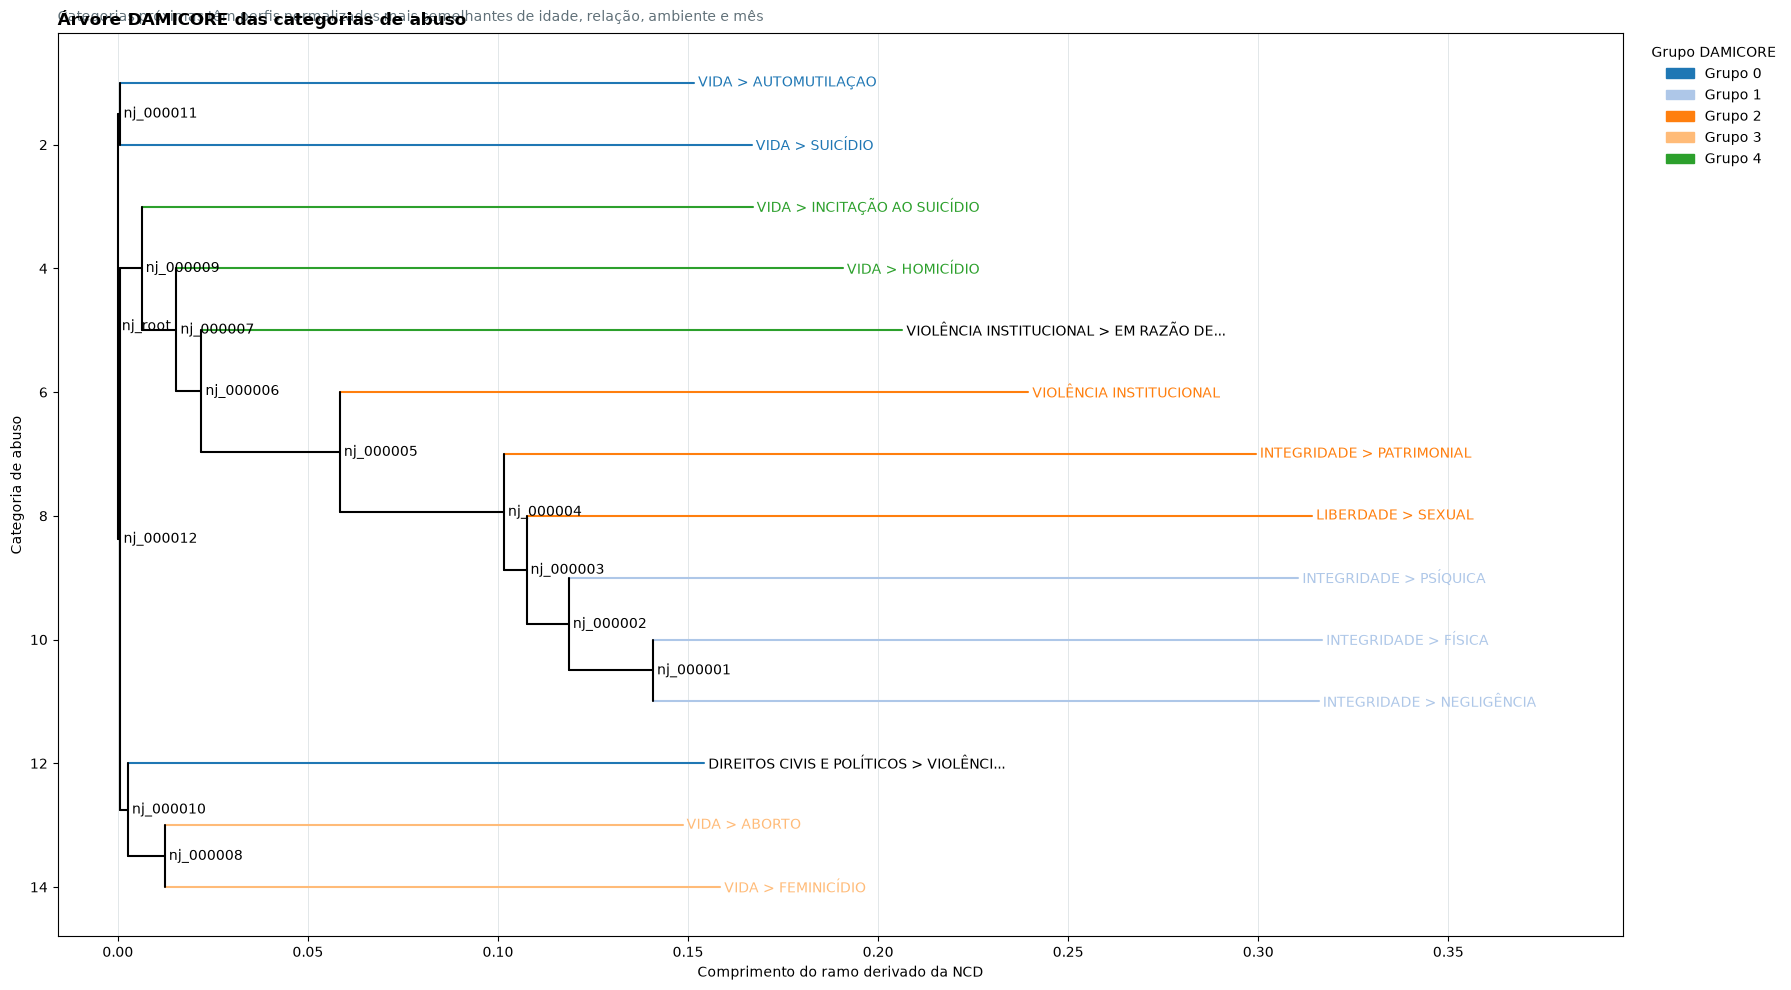

In [6]:
tree = Phylo.read(StringIO(tree_newick), "newick")
by_object_id = category_clusters.set_index("object_id")
by_label = category_clusters.set_index("label")
label_colors = {}

for terminal in tree.get_terminals():
    if terminal.name in by_object_id.index:
        category_row = by_object_id.loc[terminal.name]
    elif terminal.name in by_label.index:
        category_row = by_label.loc[terminal.name]
    else:
        raise KeyError(f"Folha desconhecida na árvore DAMICORE: {terminal.name}")
    cluster = int(category_row["cluster"])
    terminal.name = category_row["category"]
    terminal.color = cluster_hex_colors[cluster]
    label_colors[terminal.name] = cluster_hex_colors[cluster]

figure_height = max(10, len(category_clusters) * 0.34)
figure, axis = plt.subplots(figsize=(18, figure_height))
Phylo.draw(
    tree,
    axes=axis,
    do_show=False,
    show_confidence=False,
    label_colors=label_colors,
)
axis.set_title("Árvore DAMICORE das categorias de abuso", loc="left", weight="bold")
axis.text(
    0, 1.01,
    "Categorias próximas têm perfis normalizados mais semelhantes de idade, relação, ambiente e mês",
    transform=axis.transAxes, color="#607078", fontsize=10, va="bottom",
)
axis.set_xlabel("Comprimento do ramo derivado da NCD")
axis.set_ylabel("Categoria de abuso")
axis.legend(
    handles=[Patch(color=cluster_hex_colors[cluster], label=f"Grupo {cluster}") for cluster in clusters],
    title="Grupo DAMICORE", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False,
)
axis.grid(axis="x", color="#E2E7E9", linewidth=0.7)
figure.tight_layout()
figure.savefig(RESULTS_DIR / "category-tree.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


## 6. Grafo 1 — cluster DAMICORE e categoria de abuso

Cada aresta vem diretamente da associação DAMICORE. Nós de categoria maiores e arestas mais espessas indicam mais denúncias distintas.


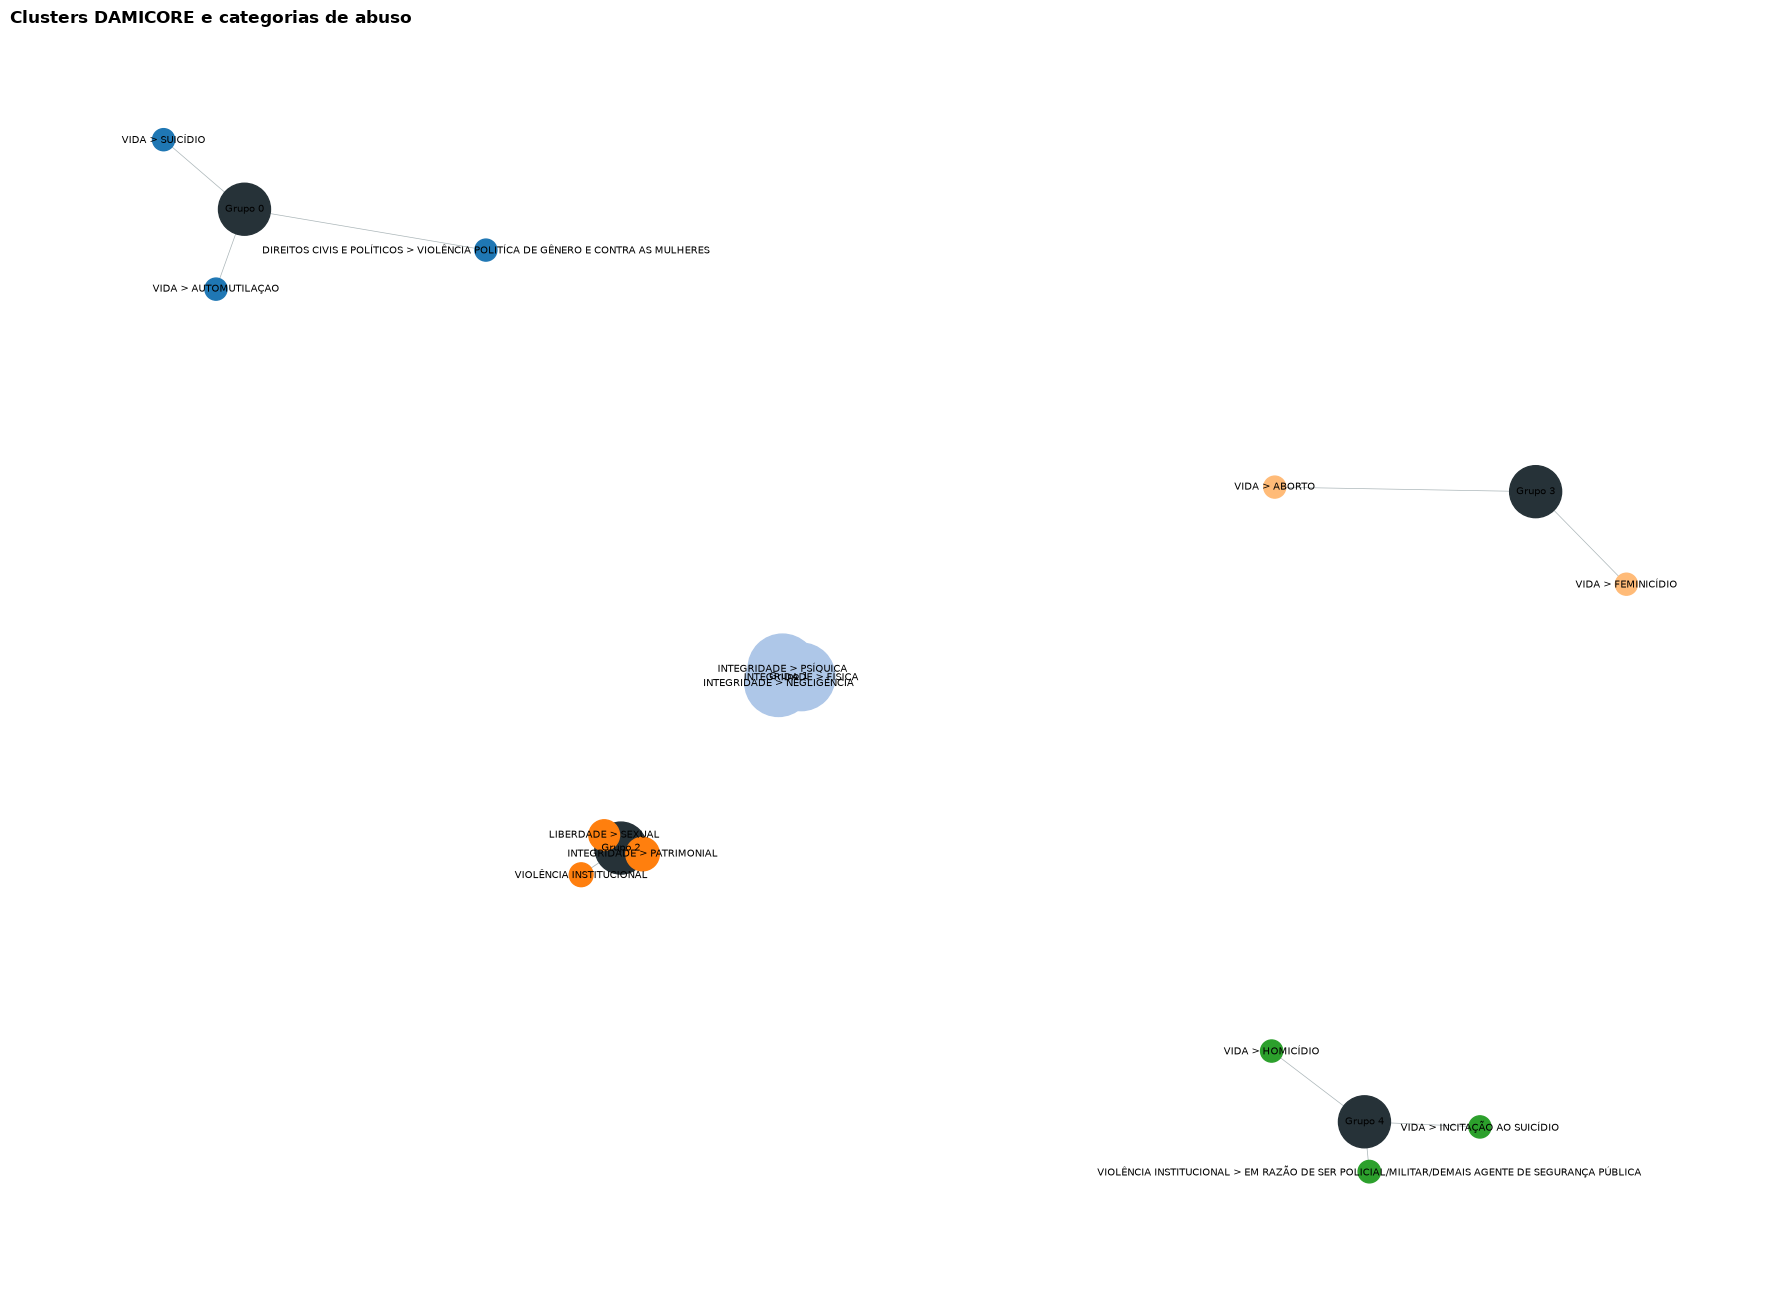

In [7]:
cluster_graph = nx.Graph(experiment="DAMICORE categorias de abuso 2026 primeiro semestre")
for row in category_clusters.itertuples(index=False):
    cluster_node = f"cluster:{row.cluster}"
    category_node = f"category:{row.label}"
    cluster_graph.add_node(cluster_node, node_type="cluster", label=f"Grupo {row.cluster}")
    cluster_graph.add_node(
        category_node, node_type="category", label=row.category,
        cluster=int(row.cluster), report_count=int(row.report_count),
    )
    cluster_graph.add_edge(cluster_node, category_node, report_count=int(row.report_count))

for cluster in category_clusters["cluster"].unique():
    node = f"cluster:{cluster}"
    cluster_graph.nodes[node]["report_count"] = int(
        category_clusters.loc[category_clusters["cluster"] == cluster, "report_count"].sum()
    )

nx.write_graphml(cluster_graph, RESULTS_DIR / "category-clusters.graphml")

max_support = category_clusters["report_count"].max()
positions = nx.spring_layout(cluster_graph, seed=42, weight="report_count", k=1.4)
node_sizes = [
    1400 if data["node_type"] == "cluster"
    else 250 + 2200 * data["report_count"] / max_support
    for _, data in cluster_graph.nodes(data=True)
]
node_colors = [
    "#263238" if data["node_type"] == "cluster" else cluster_colors[data["cluster"]]
    for _, data in cluster_graph.nodes(data=True)
]
edge_widths = [0.5 + 5 * data["report_count"] / max_support for _, _, data in cluster_graph.edges(data=True)]
labels = {node: data["label"] for node, data in cluster_graph.nodes(data=True)}

figure, axis = plt.subplots(figsize=(18, 13))
nx.draw_networkx(
    cluster_graph, positions, labels=labels, ax=axis,
    node_size=node_sizes, node_color=node_colors,
    width=edge_widths, edge_color="#AAB5B8", font_size=7,
)
axis.set_title("Clusters DAMICORE e categorias de abuso", loc="left", weight="bold")
axis.axis("off")
figure.tight_layout()
figure.savefig(RESULTS_DIR / "category-clusters.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


## 7. Grafo 2 — duas categorias mais próximas pela NCD

Cada categoria se liga às duas menores distâncias que não são dela mesma. A espessura da aresta representa `1 / (1 + NCD)`; arestas mais espessas indicam maior semelhança.


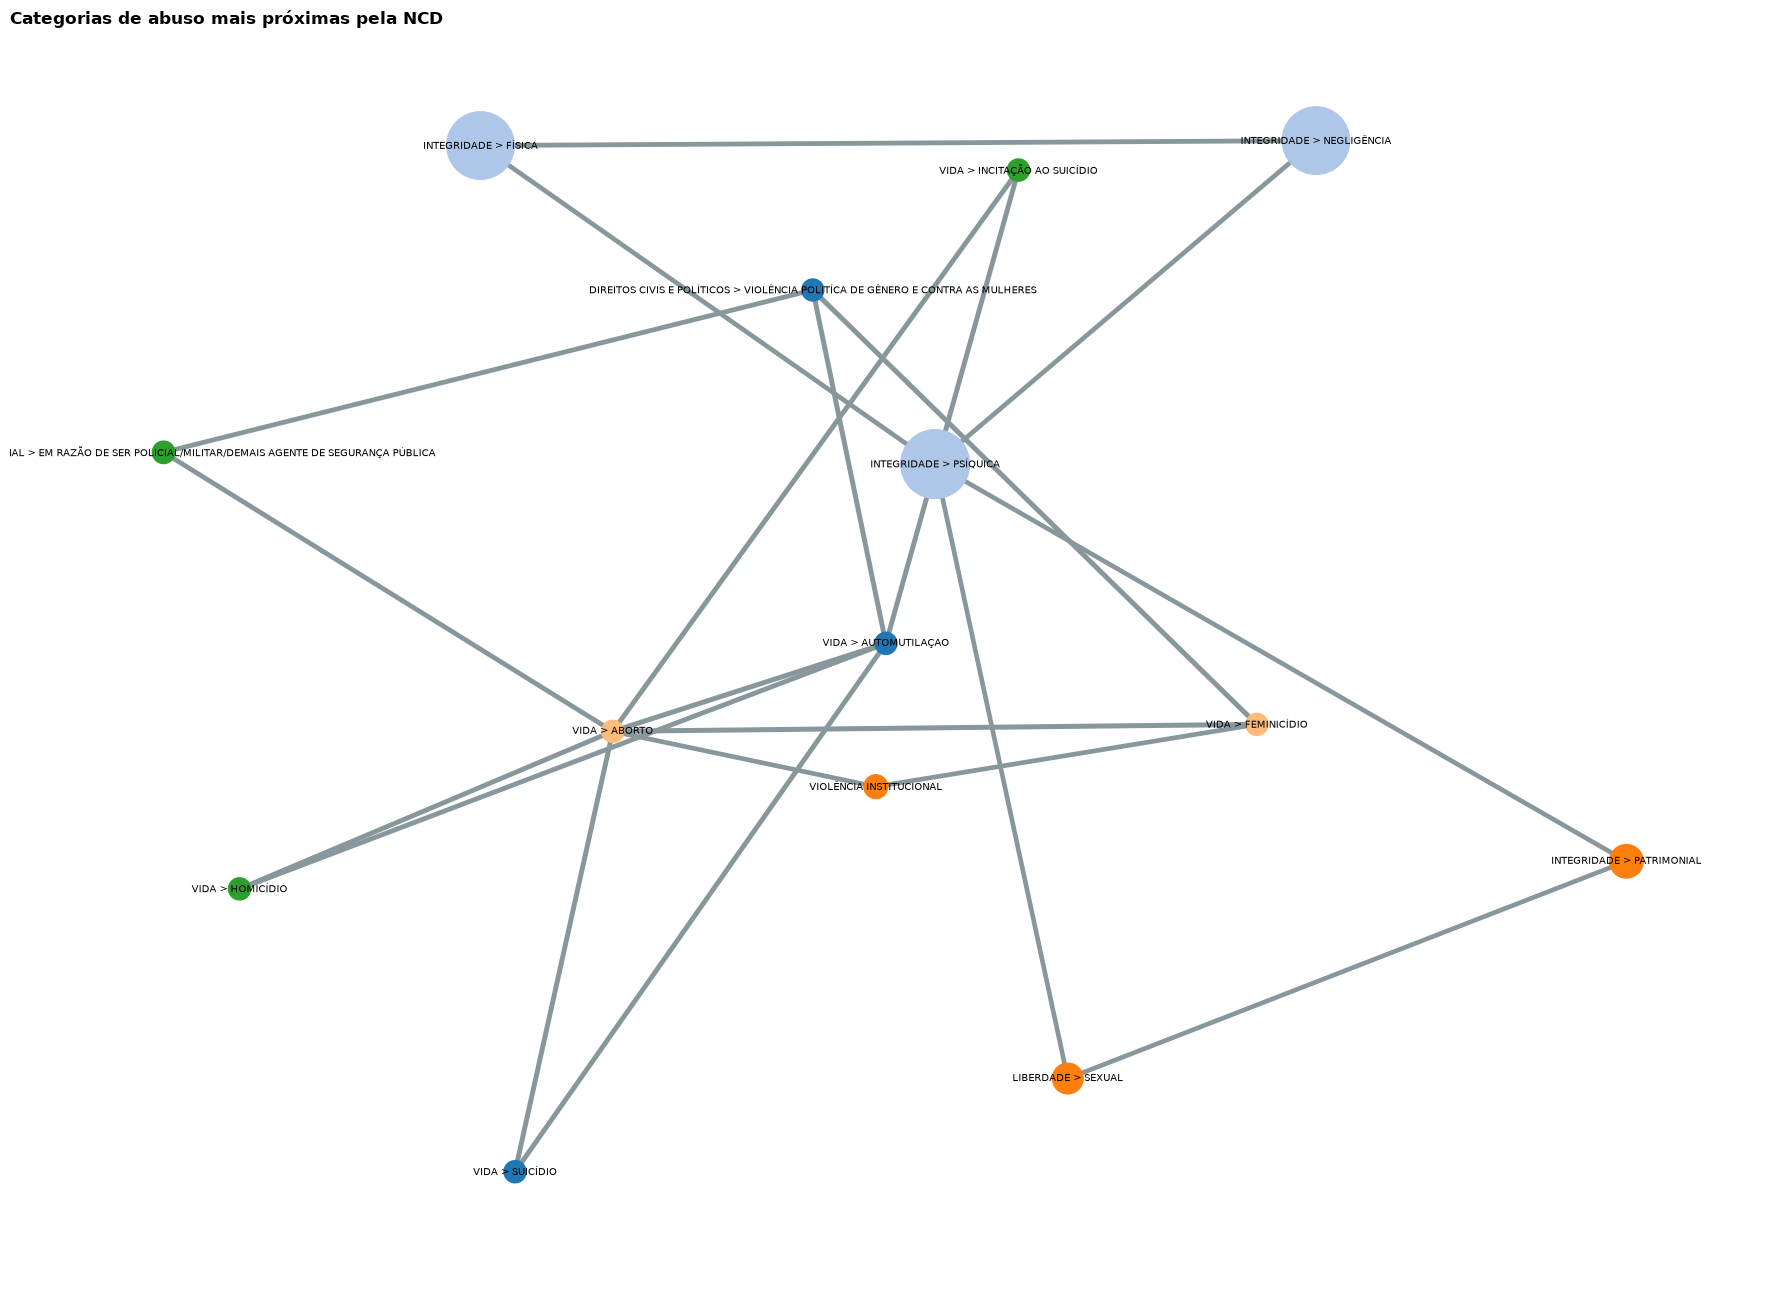

In [8]:
similarity_graph = nx.Graph(experiment="DAMICORE semelhança entre categorias 2026 primeiro semestre")
cluster_by_label = category_clusters.set_index("label")

for label, row in cluster_by_label.iterrows():
    similarity_graph.add_node(
        label, node_type="category", label=row["category"],
        cluster=int(row["cluster"]), report_count=int(row["report_count"]),
    )

for label in distance_matrix.index:
    for neighbor, ncd in distance_matrix.loc[label].drop(label).nsmallest(2).items():
        ncd = float(ncd)
        if not similarity_graph.has_edge(label, neighbor) or ncd < similarity_graph[label][neighbor]["ncd_distance"]:
            similarity_graph.add_edge(
                label, neighbor, ncd_distance=ncd, similarity=1.0 / (1.0 + ncd)
            )

nx.write_graphml(similarity_graph, RESULTS_DIR / "category-similarity.graphml")

positions = nx.spring_layout(similarity_graph, seed=42, weight="similarity", k=1.2)
node_sizes = [
    250 + 2200 * data["report_count"] / max_support
    for _, data in similarity_graph.nodes(data=True)
]
node_colors = [cluster_colors[data["cluster"]] for _, data in similarity_graph.nodes(data=True)]
edge_widths = [0.5 + 4 * data["similarity"] for _, _, data in similarity_graph.edges(data=True)]
labels = {node: data["label"] for node, data in similarity_graph.nodes(data=True)}

figure, axis = plt.subplots(figsize=(18, 13))
nx.draw_networkx(
    similarity_graph, positions, labels=labels, ax=axis,
    node_size=node_sizes, node_color=node_colors,
    width=edge_widths, edge_color="#87979B", font_size=7,
)
axis.set_title("Categorias de abuso mais próximas pela NCD", loc="left", weight="bold")
axis.axis("off")
figure.tight_layout()
figure.savefig(RESULTS_DIR / "category-similarity.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


## Limite de interpretação

O DAMICORE agrupa categorias elegíveis da fonte cujos perfis normalizados de prevalência demográfica, do processo de registro, da relação, do ambiente e do mês são comprimidos de forma semelhante. Interprete a árvore e os grafos somente quando o diagnóstico de viés for aceitável. Mesmo assim, os clusters são perfis contextuais exploratórios, não tipologias jurídicas ou sociais confirmadas de abuso; as categorias esparsas excluídas precisam de uma análise descritiva separada.
